In [1]:
import os
import time
import joblib
import numpy as np
import polars as pl
import psutil

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# OPTUNA
import optuna

# XGBOOST
from xgboost import XGBClassifier

/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# 1. CARGA
# ==========================================
path_df = "../../DATASETS/dataSets_Reducidos/ton_iot/datos_TON_IoT_redux.csv"

df = pl.read_csv(path_df)

print(df.shape)
print(df.head())

# ==========================================
# 2. LIMPIEZA
# ==========================================
df = df.drop_nulls()

# ==========================================
# 3. SEPARAR TARGET Y FEATURES
# ==========================================

target_col = "label"

cols_to_drop = [
    "label",
    "type",
    "src_ip",
    "dst_ip"
]

X = df.drop(cols_to_drop).to_pandas()
y = df[target_col].to_numpy()

# ==========================================
# 4. SPLIT 80/20
# ==========================================

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================
# 5. SPLIT TRAIN / VALIDACIÓN
# ==========================================

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

# ==========================================
# 6. PREPROCESAMIENTO
# ==========================================

categorical_cols = ["proto", "conn_state"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("Numéricas:", numeric_cols)
print("Categóricas:", categorical_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ]
)

# Transformar
X_train_np = preprocessor.fit_transform(X_train)
X_val_np = preprocessor.transform(X_val)
X_test_np = preprocessor.transform(X_test)

# También necesitamos transformar el conjunto completo de entrenamiento para cross-validation
X_full_train_np = preprocessor.transform(X_train_full)
y_full_train = y_train_full
y_test_np = y_test

print("Shapes:")
print("Train:", X_train_np.shape)
print("Val:", X_val_np.shape)
print("Test:", X_test_np.shape)

(211043, 13)
shape: (5, 13)
┌──────────────┬──────────┬──────────────┬──────────┬───┬──────────┬────────────┬───────┬──────────┐
│ src_ip       ┆ src_port ┆ dst_ip       ┆ dst_port ┆ … ┆ dst_pkts ┆ conn_state ┆ label ┆ type     │
│ ---          ┆ ---      ┆ ---          ┆ ---      ┆   ┆ ---      ┆ ---        ┆ ---   ┆ ---      │
│ str          ┆ i64      ┆ str          ┆ i64      ┆   ┆ i64      ┆ str        ┆ i64   ┆ str      │
╞══════════════╪══════════╪══════════════╪══════════╪═══╪══════════╪════════════╪═══════╪══════════╡
│ 192.168.1.37 ┆ 4444     ┆ 192.168.1.19 ┆ 49178    ┆ … ┆ 31       ┆ OTH        ┆ 1     ┆ backdoor │
│              ┆          ┆ 3            ┆          ┆   ┆          ┆            ┆       ┆          │
│ 192.168.1.19 ┆ 49180    ┆ 192.168.1.37 ┆ 8080     ┆ … ┆ 1        ┆ REJ        ┆ 1     ┆ backdoor │
│ 3            ┆          ┆              ┆          ┆   ┆          ┆            ┆       ┆          │
│ 192.168.1.19 ┆ 49180    ┆ 192.168.1.37 ┆ 8080     ┆ … ┆ 1    

In [ ]:
def objective(trial):
    # 1. Sugerir hiperparámetros
    n_estimators = trial.suggest_int("n_estimators", 50, 600, step=50)
    max_depth = trial.suggest_int("max_depth", 2, 12)
    
    # 2. Configurar el Validador Cruzado (3 Folds Estratificados)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    f1_scores = []
    latencies = []

    # 3. Bucle de Cross-Validation
    # ATENCIÓN: Usamos los nombres exactos de los arrays generados en el split anterior
    for train_idx, val_idx in skf.split(X_full_train_np, y_full_train):
        # Dividir datos del fold
        X_train_cv, X_val_cv = X_full_train_np[train_idx], X_full_train_np[val_idx]
        y_train_cv, y_val_cv = y_full_train[train_idx], y_full_train[val_idx]

        # 3) Modelo XGBoost
        model = XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,

            learning_rate=0.1, # Tasa de aprendizaje fijada

            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            
            # Aceleración del hardware
            tree_method="hist",
            device="cuda",
        )

        # Entrenamiento del fold
        model.fit(X_train_cv, y_train_cv)

        # Inferencia en CPU para que Pareto refleje el escenario de despliegue
        model.set_params(device="cpu")

        # Predicción y métrica de eficacia (F1)
        y_pred = model.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv, y_pred, average='binary'))

        # Medición de eficiencia (Latencia) en este fold
        subset = min(20000, len(X_val_cv)) 
        X_lat = X_val_cv[:subset]

        # Warm-up rápido para estabilizar la inferencia
        _ = model.predict(X_lat[:min(500, len(X_lat))])

        rep_lat = []
        for _ in range(3): 
            t0 = time.perf_counter()
            _ = model.predict(X_lat)
            t1 = time.perf_counter()
            rep_lat.append((t1 - t0) / len(X_lat) * 1000)

        latencies.append(float(np.mean(rep_lat)))

    # 4. Promediar resultados de los 3 folds
    avg_f1 = np.mean(f1_scores)
    avg_lat = np.mean(latencies)
    std_f1 = np.std(f1_scores) 

    # Guardamos atributos extra para el análisis posterior
    trial.set_user_attr("f1_std", std_f1)

    return avg_f1, avg_lat

# --- EJECUCIÓN ---

study = optuna.create_study(
    directions=["maximize", "minimize"],
    study_name="iot23_xgboost_optimization_cv"
)

print("🚀 Iniciando barrido multiobjetivo con 3-Fold Cross-Validation para IoT-23...")
print("Nota: Cada trial ahora entrena 3 modelos. Evaluando F1 Binario (Benigno vs Malicioso).")

# Puedes reducir n_trials si ves que tarda demasiado por el tamaño del dataset
study.optimize(objective, n_trials=50)

# ==========================================
# EXTRACCIÓN DE DATOS A POLARS
# ==========================================

trials_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trials_data.append({
            "n_estimators": t.params["n_estimators"],
            "max_depth": t.params["max_depth"],
            "f1_binary": t.values[0],
            "f1_std": t.user_attrs["f1_std"],
            "latency_ms": t.values[1],
            "is_pareto": t in study.best_trials 
        })

df_results = pl.DataFrame(trials_data)
df_results.write_csv("xgboost_ton_trials_results_cv.csv")

print("\n✅ Resultados robustos guardados en 'xgboost_ton_trials_results_cv.csv'")
print(df_results.sort("f1_binary", descending=True).head())

[I 2026-04-29 21:19:54,647] A new study created in memory with name: iot23_xgboost_optimization_cv


🚀 Iniciando barrido multiobjetivo con 3-Fold Cross-Validation para IoT-23...
Nota: Cada trial ahora entrena 3 modelos. Evaluando F1 Binario (Benigno vs Malicioso).


[I 2026-04-29 21:19:55,691] Trial 0 finished with values: [0.9968834591888713, 0.00012502063311532969] and parameters: {'n_estimators': 550, 'max_depth': 2}.
[I 2026-04-29 21:19:57,715] Trial 1 finished with values: [0.9981527315179748, 0.00028292789486133383] and parameters: {'n_estimators': 350, 'max_depth': 12}.
[I 2026-04-29 21:19:58,012] Trial 2 finished with values: [0.9967182055349398, 5.724773768128621e-05] and parameters: {'n_estimators': 50, 'max_depth': 5}.
[I 2026-04-29 21:19:58,682] Trial 3 finished with values: [0.9980595962981033, 9.965277212258015e-05] and parameters: {'n_estimators': 150, 'max_depth': 7}.
[I 2026-04-29 21:19:59,996] Trial 4 finished with values: [0.9981836205937563, 0.00016947281676241093] and parameters: {'n_estimators': 200, 'max_depth': 12}.
[I 2026-04-29 21:20:01,213] Trial 5 finished with values: [0.9981642723643135, 0.00016190538881346586] and parameters: {'n_estimators': 250, 'max_depth': 9}.
[I 2026-04-29 21:20:01,671] Trial 6 finished with val


✅ Resultados robustos guardados en 'xgboost_iot23_trials_results_cv.csv'
shape: (5, 6)
┌──────────────┬───────────┬───────────┬──────────┬────────────┬───────────┐
│ n_estimators ┆ max_depth ┆ f1_binary ┆ f1_std   ┆ latency_ms ┆ is_pareto │
│ ---          ┆ ---       ┆ ---       ┆ ---      ┆ ---        ┆ ---       │
│ i64          ┆ i64       ┆ f64       ┆ f64      ┆ f64        ┆ bool      │
╞══════════════╪═══════════╪═══════════╪══════════╪════════════╪═══════════╡
│ 550          ┆ 6         ┆ 0.998257  ┆ 0.000061 ┆ 0.000212   ┆ true      │
│ 350          ┆ 6         ┆ 0.998226  ┆ 0.000047 ┆ 0.000155   ┆ true      │
│ 450          ┆ 6         ┆ 0.998226  ┆ 0.000038 ┆ 0.000183   ┆ false     │
│ 500          ┆ 7         ┆ 0.998195  ┆ 0.000058 ┆ 0.000228   ┆ false     │
│ 450          ┆ 7         ┆ 0.998191  ┆ 0.000052 ┆ 0.000208   ┆ false     │
└──────────────┴───────────┴───────────┴──────────┴────────────┴───────────┘


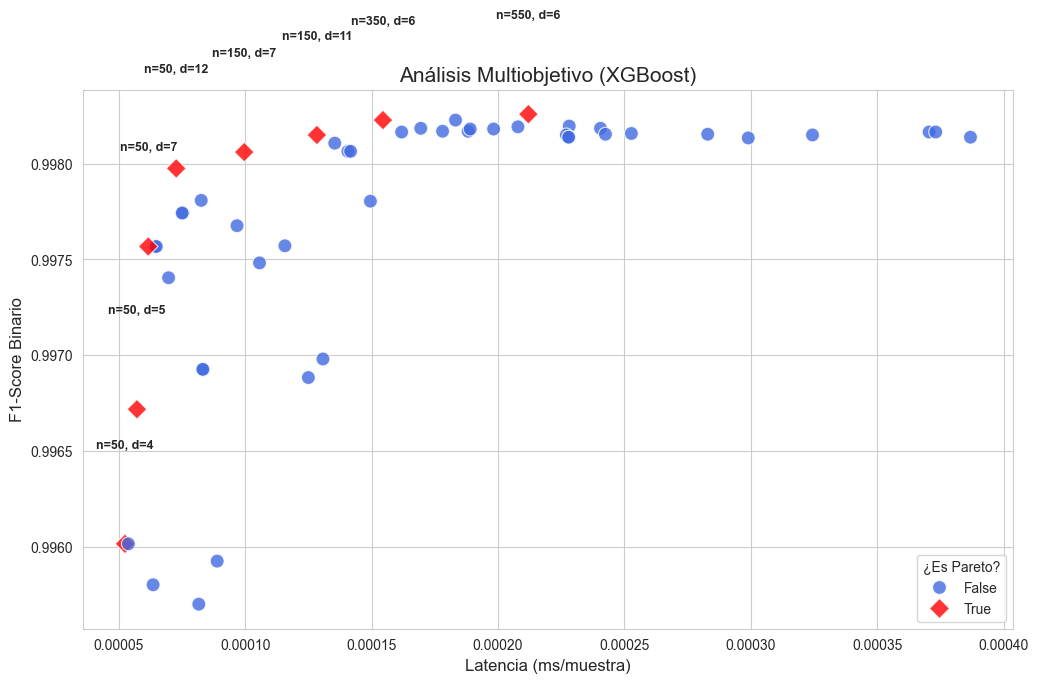

In [7]:
# ==========================================
# GRAFICA PARETO (Polars + NumPy Edition)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

df = pl.read_csv("xgboost_ton_trials_results_cv.csv")

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

sns.scatterplot(
    x=df["latency_ms"].to_numpy(),
    y=df["f1_binary"].to_numpy(),
    hue=df["is_pareto"].to_numpy(),
    palette={True: "red", False: "royalblue"},
    style=df["is_pareto"].to_numpy(),
    markers={True: "D", False: "o"},
    s=100,
    alpha=0.8
)

pareto_points = df.filter(pl.col("is_pareto") == True)

for row in pareto_points.iter_rows(named=True):
    plt.text(
        row["latency_ms"],
        row["f1_binary"] + 0.0005,
        f"n={int(row['n_estimators'])}, d={int(row['max_depth'])}",
        fontsize=9, fontweight='bold', ha='center'
    )

plt.title("Análisis Multiobjetivo (XGBoost)", fontsize=15)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Binario", fontsize=12)
plt.legend(title="¿Es Pareto?")

plt.show()

/tmp/ipykernel_3335823/3513967840.py:38: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


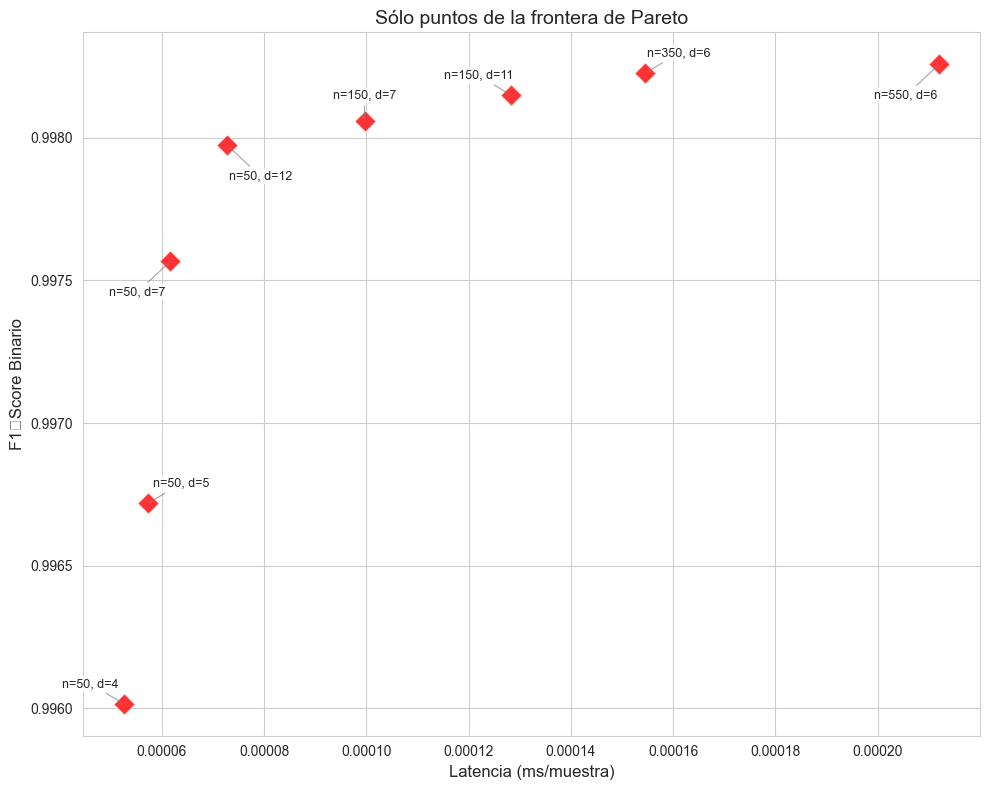

n_estimators,max_depth,f1_binary,f1_std,latency_ms,is_pareto
i64,i64,f64,f64,f64,bool
50,4,0.996016,0.000085,0.000053,true
50,5,0.996718,0.000266,0.000057,true
50,7,0.997567,0.000106,0.000062,true
50,12,0.997974,0.000053,0.000073,true
150,7,0.99806,0.000033,0.0001,true
150,11,0.998149,0.000053,0.000128,true
350,6,0.998226,0.000047,0.000155,true
550,6,0.998257,0.000061,0.000212,true


In [8]:
# AHORA SOLO REPRESENTAMOS LOS MODELOS DE LA FRONTERA DE PARETO

df = pl.read_csv("xgboost_ton_trials_results_cv.csv")
pareto_df = df.filter(pl.col("is_pareto") == True).sort("latency_ms")

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
ax = plt.gca()

sns.scatterplot(
    x=pareto_df["latency_ms"].to_numpy(),
    y=pareto_df["f1_binary"].to_numpy(),
    color="red",
    marker="D",
    s=120,
    alpha=0.8,
    ax=ax
)

offsets = [(-24, 10), (24, 10), (-24, -18), (24, -18), (0, 14)]
for i, row in enumerate(pareto_df.iter_rows(named=True)):
    dx, dy = offsets[i % len(offsets)]
    ax.annotate(
        f"n={int(row['n_estimators'])}, d={int(row['max_depth'])}",
        xy=(row["latency_ms"], row["f1_binary"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=9,
        ha="center",
        va="bottom" if dy >= 0 else "top",
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1.5),
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.8, alpha=0.7)
    )

plt.title("Sólo puntos de la frontera de Pareto", fontsize=14)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1‑Score Binario", fontsize=12)
plt.tight_layout()
plt.show()

display(pareto_df)

In [6]:
# ==========================================
# EVALUACIÓN FINAL EN TEST (3 CANDIDATOS)
# ==========================================

candidatos = [
    {"n": 50, "d": 4, "nombre": "Candidato 1"},
    {"n": 50, "d": 5, "nombre": "Candidato 2"},
    {"n": 50, "d": 7, "nombre": "Candidato 3"},
    {"n": 50, "d": 12, "nombre": "Candidato 4"},
    {"n": 150, "d": 7, "nombre": "Candidato 5"},
    {"n": 150, "d": 11, "nombre": "Candidato 6"},
    {"n": 350, "d": 6, "nombre": "Candidato 7"},
    {"n": 550, "d": 6, "nombre": "Candidato 7"},
]

resultados_finales = []

print("--- EVALUACIÓN FINAL SOBRE EL SET DE TEST (XGBoost) ---\n")

# Convertimos y_train/y_test a 0/1 para XGB
y_full_train01 = ((y_full_train + 1) // 2).astype(np.int8)
y_test_np01    = ((y_test_np + 1) // 2).astype(np.int8)

for c in candidatos:
    print(f"Probando: {c['nombre']} (n={c['n']}, d={c['d']})...")

    model = XGBClassifier(
            n_estimators=c["n"],
            max_depth=c["d"],
            learning_rate=0.1,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,

            # Entrenamiento acelerado en GPU
            tree_method="hist",
            device="cuda"
    )

    model.fit(X_full_train_np, y_full_train01)

    model.set_params(device="cpu")  # Inferencia en CPU para replicar el escenario real de despliegue
    # Warm-up
    _ = model.predict(X_test_np[:min(1000, len(X_test_np))])

    t0 = time.perf_counter()
    y_pred01 = model.predict(X_test_np)
    t1 = time.perf_counter()

    tiempo_total = t1 - t0
    latencia = (tiempo_total / len(y_test_np01)) * 1000
    f1_test = f1_score(y_test_np01, y_pred01, average="binary")
    acc_test = accuracy_score(y_test_np01, y_pred01)

    resultados_finales.append({
        "Perfil": c["nombre"],
        "n_estimators": c["n"],
        "max_depth": c["d"],
        "F1_Binary_Test": float(f1_test),
        "Accuracy_Test": float(acc_test),
        "Latencia_ms": float(latencia)
    })

df_final = pl.DataFrame(resultados_finales)
print("\n" + "="*60)
print("              TABLA COMPARATIVA FINAL (XGBoost)")
print("="*60)
print(df_final)

--- EVALUACIÓN FINAL SOBRE EL SET DE TEST (XGBoost) ---

Probando: Candidato 1 (n=50, d=4)...
Probando: Candidato 2 (n=50, d=5)...
Probando: Candidato 3 (n=50, d=7)...
Probando: Candidato 4 (n=50, d=12)...
Probando: Candidato 5 (n=150, d=7)...
Probando: Candidato 6 (n=150, d=11)...
Probando: Candidato 7 (n=350, d=6)...
Probando: Candidato 7 (n=550, d=6)...

              TABLA COMPARATIVA FINAL (XGBoost)
shape: (8, 6)
┌─────────────┬──────────────┬───────────┬────────────────┬───────────────┬─────────────┐
│ Perfil      ┆ n_estimators ┆ max_depth ┆ F1_Binary_Test ┆ Accuracy_Test ┆ Latencia_ms │
│ ---         ┆ ---          ┆ ---       ┆ ---            ┆ ---           ┆ ---         │
│ str         ┆ i64          ┆ i64       ┆ f64            ┆ f64           ┆ f64         │
╞═════════════╪══════════════╪═══════════╪════════════════╪═══════════════╪═════════════╡
│ Candidato 1 ┆ 50           ┆ 4         ┆ 0.995979       ┆ 0.993864      ┆ 0.00005     │
│ Candidato 2 ┆ 50           ┆ 5      